In [4]:
import os
import random
import spacy
import json
from tqdm import tqdm
from dotenv import load_dotenv
from elasticsearch import Elasticsearch
from sentence_transformers import SentenceTransformer
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
from elasticsearch.helpers import scan

from utils import create_fragments_index, segment_speech

random.seed(420)
load_dotenv()
ES_HOST = os.getenv("ES_HOST", "http://localhost:9200")
INDEX_NAME = os.getenv("INDEX_NAME")
FRAGMENT_INDEX_NAME = f"{os.getenv('INDEX_NAME')}_fragments"
CHUNK_3_SAMPLE_FRAGMENTS_INDEX_NAME = f"{os.getenv('INDEX_NAME')}_fragments_sample_chunk_3"
SAMPLE_FRAGMENTS_INDEX_NAME = f"{os.getenv('INDEX_NAME')}_fragments_sample"
es_client = Elasticsearch('http://localhost:9200')

embed_model = SentenceTransformer("all-MiniLM-L6-v2", device=os.getenv("MODEL_DEVICE", "cpu"))

#### Chunking Parameter Experiment

In [9]:
with open("../kg/data/sampled_ids_100.json", "r") as f:
    sampled_ids = json.load(f)

sample_speeches = es_client.search(
    index=INDEX_NAME,
    query={
        "terms": {
            "_id": sampled_ids
        }
    },
    size=10000
)["hits"]["hits"]

In [ ]:
semantic_threshold = [0.2, 0.4, 0.6, 0.8, 1.0]

sem_results = []

for treshold in semantic_threshold:
    speech_means = []

    for speech in tqdm(sample_speeches, desc=f"Semantic threshold: {treshold}"):
        fragments, ids = segment_speech(
            text=speech["_source"]["text"],
            semantic_threshold = treshold,
            entity_weight = 0.12,
            lexical_weight = 0.05
        )

        speech_means.append(np.mean([(end - start + 1) for start, end in ids]))

    sem_results.append(
        {
            "semantic_threshold": treshold,
            "mean": np.mean(speech_means)
        }
    )

In [72]:
sem_results

[{'semantic_threshold': 0.2, 'mean': np.float64(6.089256311009252)},
 {'semantic_threshold': 0.4, 'mean': np.float64(2.4100074509332385)},
 {'semantic_threshold': 0.6, 'mean': np.float64(1.6427379529456585)},
 {'semantic_threshold': 0.8, 'mean': np.float64(1.5611248460771734)},
 {'semantic_threshold': 1.0, 'mean': np.float64(1.5562823117707874)}]

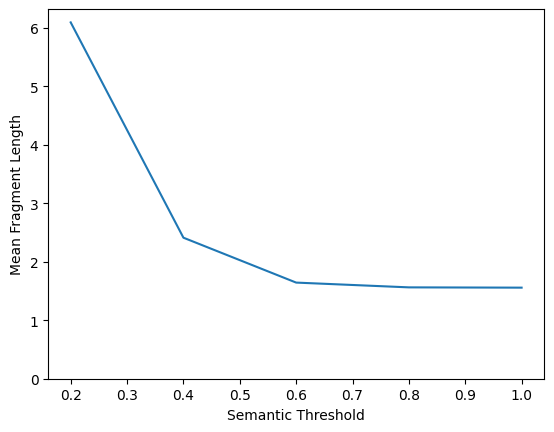

In [76]:
plt.plot([r["semantic_threshold"] for r in sem_results], [r["mean"] for r in sem_results])
plt.xlabel("Semantic Threshold")
plt.ylim(0)
plt.ylabel("Mean Fragment Length")
plt.show()

In [ ]:
entity_weights = [1, 0.5, 0.12, 0.01]
lexical_weights = [1, 0.5, 0.05, 0.01]

results = []

for entity_weight in entity_weights:
    for lexical_weight in lexical_weights:
        speech_means = []

        for speech in tqdm(sample_speeches, desc=f"Entity weight: {entity_weight}, Lexical weight: {lexical_weight}"):
            fragments, ids = segment_speech(
                text=speech["_source"]["text"],
                semantic_threshold = 0.4,
                entity_weight = entity_weight,
                lexical_weight = lexical_weight
            )

            speech_means.append(np.mean([(end - start + 1) for start, end in ids]))

        results.append(
            {
                "entity_weight": entity_weight,
                "lexical_weight": lexical_weight,
                "mean": np.mean(speech_means)
            }
        )

In [66]:
res_df = pd.DataFrame(results)
(
    res_df.pivot(
        index="entity_weight",
        columns="lexical_weight",
        values="mean"
    )
    .rename_axis(index="Entity weight", columns="Lexical weight")
)

Lexical weight,0.01,0.05,0.50,1.00
Entity weight,,,,
0.01,2.390395,2.391648,2.529712,2.617779
0.12,2.406399,2.410007,2.551729,2.623408
0.50,2.443422,2.444677,2.565242,2.634778
1.00,2.449026,2.450281,2.572100,2.641463


### Creating whole fragments index

In [3]:
# create_fragments_index(
#     es_client=es_client,
#     dataset_path="../data/putin_complete.json",
#     n_speeches=1000
# )

### Create sample fragment indices for tests

In [ ]:
# For testing purposes, I limit the number of speeches to 100

es_client.indices.delete(index=CHUNK_3_SAMPLE_FRAGMENTS_INDEX_NAME, ignore=[400, 404])
es_client.indices.create(index=CHUNK_3_SAMPLE_FRAGMENTS_INDEX_NAME, ignore=400)

es_client.indices.delete(index=SAMPLE_FRAGMENTS_INDEX_NAME, ignore=[400, 404])
es_client.indices.create(index=SAMPLE_FRAGMENTS_INDEX_NAME, ignore=400)

/tmp/ipykernel_54216/1775663582.py:5: DeprecationWarning: Passing transport options in the API method is deprecated. Use 'Elasticsearch.options()' instead.
  es_client.indices.delete(index=CHUNK_3_SAMPLE_FRAGMENTS_INDEX_NAME, ignore=[400, 404])
/tmp/ipykernel_54216/1775663582.py:6: DeprecationWarning: Passing transport options in the API method is deprecated. Use 'Elasticsearch.options()' instead.
  es_client.indices.create(index=CHUNK_3_SAMPLE_FRAGMENTS_INDEX_NAME, ignore=400)
/tmp/ipykernel_54216/1775663582.py:8: DeprecationWarning: Passing transport options in the API method is deprecated. Use 'Elasticsearch.options()' instead.
  es_client.indices.delete(index=SAMPLE_FRAGMENTS_INDEX_NAME, ignore=[400, 404])
/tmp/ipykernel_54216/1775663582.py:9: DeprecationWarning: Passing transport options in the API method is deprecated. Use 'Elasticsearch.options()' instead.
  es_client.indices.create(index=SAMPLE_FRAGMENTS_INDEX_NAME, ignore=400)


ObjectApiResponse({'acknowledged': True, 'shards_acknowledged': True, 'index': 'russian_speeches_fragments_sample'})

In [ ]:
N_sample = 1000

speeches = es_client.search(
    index=INDEX_NAME,
    query={
        "match_all": {}
    },
    size=10000
)["hits"]["hits"]

sampled = random.sample(speeches, N_sample)
sampled_ids = [speech["_id"] for speech in sampled]

In [ ]:
sampled_ids = [speech["_id"] for speech in sampled]
with open("../kg/data/sampled_ids.json", "w") as f:
    json.dump(sampled_ids, f)

In [3]:
def segment_speech_by_size(text: str, chunk_size: int = 3):
    nlp = spacy.load("en_core_web_sm")

    doc = nlp(text)

    sentences = [
        sent.text.strip()
        for sent in doc.sents
        if sent.text and sent.text.strip()
    ]

    if not sentences:
        return [], []

    fragments = []
    fragment_ranges = []

    for start_idx in range(0, len(sentences), chunk_size):
        end_idx = min(start_idx + chunk_size, len(sentences))

        chunk_sentences = sentences[start_idx:end_idx]

        fragments.append(" ".join(chunk_sentences))

        fragment_ranges.append(
            (start_idx, end_idx - 1)
        )

    return fragments, fragment_ranges

In [5]:
frag_id = 0
for s in tqdm(sampled, "Processing speeches"):
    fragments, fragment_ranges = segment_speech_by_size(s["_source"]["text"])
    for idx, fragment in enumerate(fragments):
        frag_id += 1

        embedding = embed_model.encode(
            fragment,
            normalize_embeddings=True
        ).tolist()

        start_idx, end_idx = fragment_ranges[idx]

        frag_doc = {
            "speech_id": s["_id"],
            "chunk_start": start_idx,
            "chunk_end": end_idx,
            "title": s["_source"].get("title", None),
            "date": s["_source"].get("date", None),
            "text": fragment,
            "embedding": embedding,
        }
        speech_author = es_client.search(
            index=FRAGMENT_INDEX_NAME,
            query={
                "match": {"speech_id": 10}
            },
            size=10000
        )["hits"]["hits"][0]["_source"].get("author", "Unknown")
        if speech_author and len(speech_author) < 100:
            frag_doc["author"] = speech_author

        es_client.index(
            index=CHUNK_3_SAMPLE_FRAGMENTS_INDEX_NAME,
            id=frag_id,
            document=frag_doc
        )


Processing speeches: 100%|██████████| 1000/1000 [10:26<00:00,  1.60it/s]


In [7]:
with open("../kg/data/sampled_ids.json", "r") as f:
    sampled_ids = json.load(f)
for i in range(0, len(sampled_ids), 10):
    batch_ids = sampled_ids[i:i + 10]

    sampled_fragments = es_client.search(
        index=FRAGMENT_INDEX_NAME,
        query={
            "terms": {
                "speech_id": batch_ids
            }
        },
        size=10000
    )["hits"]["hits"]

    for hit in sampled_fragments:
        es_client.index(
            index=SAMPLE_FRAGMENTS_INDEX_NAME,
            id=hit["_id"],
            document=hit["_source"]
        )

In [8]:
es_client.count(
    index=SAMPLE_FRAGMENTS_INDEX_NAME
)["count"]

1824

In [9]:
sampled_speeches = es_client.search(
    index=INDEX_NAME,
    query={
        "terms": {
            "_id": sampled_ids
        }
    },
    size=10000
)["hits"]["hits"]

In [10]:
len(sampled_fragments), len(sampled_speeches)

(198, 100)

In [11]:
sample_dates = [hit["_source"]["date"] for hit in sampled_speeches if hit["_source"].get("date")]
all_set_dates = [
    hit["_source"]["date"]
    for hit in scan(
        es_client,
        index=INDEX_NAME,
        query={
            "query": {
                "match_all": {}
            }
        }
    )
]

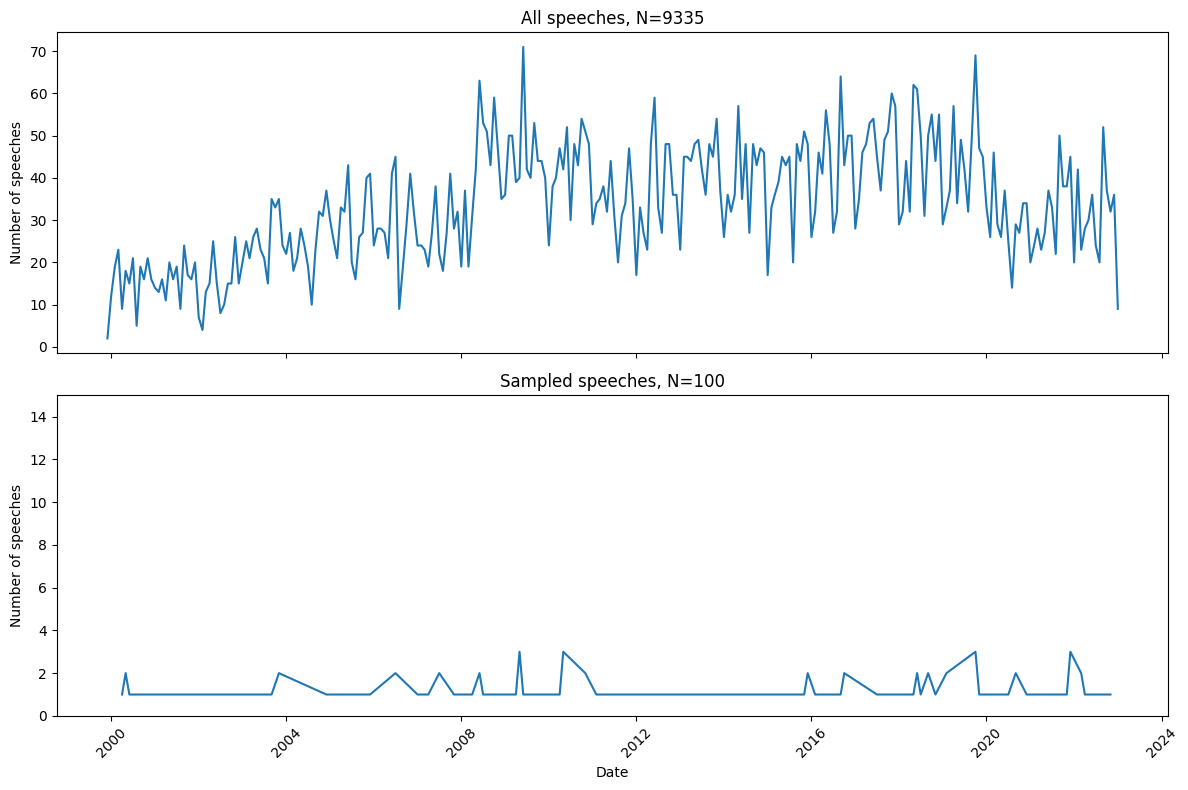

In [12]:
df_all = pd.DataFrame({
    "date": pd.to_datetime(all_set_dates)
})

df_sample = pd.DataFrame({
    "date": pd.to_datetime(sample_dates)
})

monthly_counts_all = (
    df_all
    .groupby(df_all["date"].dt.to_period("M"))
    .size()
    .reset_index(name="count")
)

monthly_counts_all_sampled = (
    df_sample
    .groupby(df_sample["date"].dt.to_period("M"))
    .size()
    .reset_index(name="count")
)

monthly_counts_all["date"] = monthly_counts_all["date"].dt.to_timestamp()
monthly_counts_all_sampled["date"] = monthly_counts_all_sampled["date"].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(
    monthly_counts_all["date"],
    monthly_counts_all["count"]
)
axes[0].set_title(f"All speeches, N={len(all_set_dates)}")
axes[0].set_ylabel("Number of speeches")

axes[1].set_ylim(bottom=0, top=15)

axes[1].plot(
    monthly_counts_all_sampled["date"],
    monthly_counts_all_sampled["count"]
)
axes[1].set_title(f"Sampled speeches, N={len(sample_dates)}")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Number of speeches")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()